Image loaded successfully.


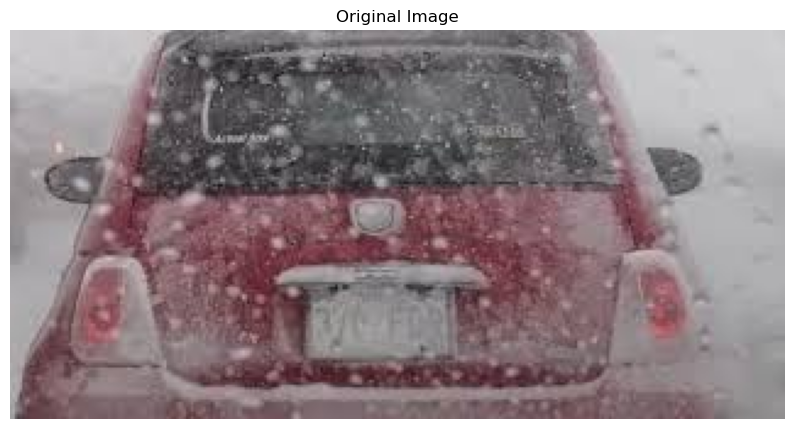

Number of Plates Detected: 1


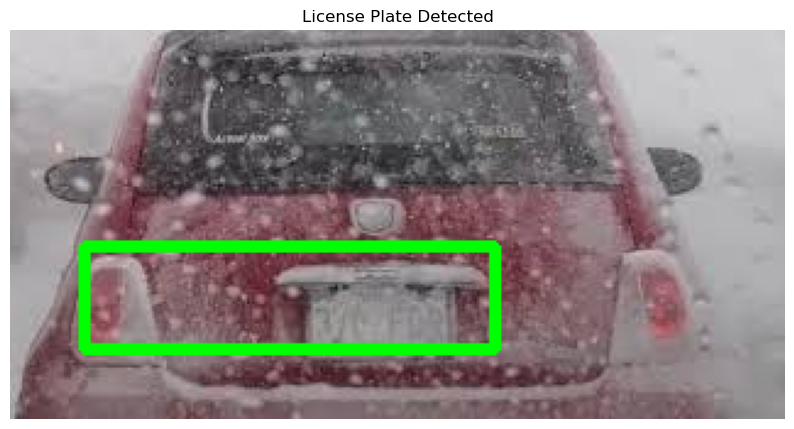

In [9]:
import cv2
import matplotlib.pyplot as plt

# Function to display image
def display(img, title):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,6))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Load image
img = cv2.imread(r"C:\Users\admin\OneDrive\Pictures\images.jpg")

if img is None:
    print("Error: Image not loaded!")
else:
    print("Image loaded successfully.")

# Load Haar Cascade
plate_cascade = cv2.CascadeClassifier(
    r"C:\Users\admin\Downloads\haarcascade_licence_plate_rus_16stages.xml"
)

if plate_cascade.empty():
    print("Error: Cascade file not loaded!")

# Display Original Image
display(img, "Original Image")

# Create copy for detection
img_detected = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img_detected, cv2.COLOR_BGR2GRAY)

# Detect plates
plates = plate_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,
    minNeighbors=2,
    minSize=(30,30)
)

print("Number of Plates Detected:", len(plates))

# Draw rectangle around detected plates
for (x, y, w, h) in plates:
    cv2.rectangle(
        img_detected,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        3
    )

# Display Detected Image
display(img_detected, "License Plate Detected")